# Comparación final de modelos de detección de reuso de código

Este notebook consolida los resultados de todos los modelos construidos durante el proyecto y los compara bajo las mismas métricas de validación.

Se incluyen tanto los modelos que ya existían como los modelos generados después:

- Baseline clásico con TF-IDF del notebook 03.
- Modelos clásicos sobre embeddings de CodeBERT del notebook 04.
- Red neuronal personalizada sobre embeddings del notebook 05.
- Modelo híbrido de embeddings + features baseline del notebook 06.
- Red neuronal Keras sobre TF-IDF del notebook 07.

El objetivo no es entrenar todo desde cero, sino evaluar de forma ordenada qué enfoque fue más efectivo, qué errores cometió cada uno y cuál conviene seleccionar como modelo final.


## 1. Imports y rutas

Se cargan las librerías necesarias para leer reportes, consolidar métricas, visualizar resultados y analizar errores.

Todos los archivos se toman desde data/reports, porque cada notebook anterior ya guardó sus resultados en CSV.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 120)

DATASET_PATH = Path('data')
REPORTS_PATH = DATASET_PATH / 'reports'
MODELS_PATH = DATASET_PATH / 'models'

REPORTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print('REPORTS_PATH existe:', REPORTS_PATH.exists())
print('MODELS_PATH existe:', MODELS_PATH.exists())


REPORTS_PATH existe: True
MODELS_PATH existe: True


## 2. Inventario de reportes disponibles

Antes de comparar, se listan los reportes encontrados. Esto ayuda a verificar qué etapas están disponibles y evita asumir resultados que no existen en disco.


In [2]:
available_reports = sorted([path.name for path in REPORTS_PATH.glob('*.csv')])
print('Reportes encontrados:', len(available_reports))
for file_name in available_reports:
    print('-', file_name)


Reportes encontrados: 25
- 03_baseline_model_results.csv
- 03_val_predictions_baseline.csv
- 04B_custom_mlp_comparison.csv
- 04B_custom_mlp_threshold_results.csv
- 04B_custom_mlp_training_history.csv
- 04_comparison_baseline_vs_transformer.csv
- 04_transformer_embedding_model_results.csv
- 04_val_predictions_transformer_embeddings.csv
- 05_custom_mlp_comparison.csv
- 05_custom_mlp_val_predictions.csv
- 06_comparison_all_models.csv
- 06_hybrid_model_results.csv
- 06_hybrid_val_predictions.csv
- 07_comparison_tfidf_keras.csv
- 07_tfidf_keras_config_search.csv
- 07_tfidf_keras_results.csv
- 07_tfidf_keras_threshold_results.csv
- 07_tfidf_keras_training_history.csv
- 07_tfidf_keras_val_predictions.csv
- comparation_all_model_candidates.csv
- comparation_best_by_stage.csv
- comparation_best_overall.csv
- comparation_error_summary.csv
- comparation_prediction_error_overlap.csv
- comparation_selected_final_model.csv


## 3. Función para cargar resultados de modelos

Cada notebook guardó sus métricas con columnas similares: accuracy, precision, recall, F1 y matriz de confusión.

La función read_results estandariza esos reportes y añade columnas de etapa, familia y archivo fuente. También permite tomar solo el mejor resultado cuando el archivo contiene búsquedas por threshold o configuración.


In [3]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp']

def read_results(stage, file_name, family=None, use_best_only=False):
    path = REPORTS_PATH / file_name

    if not path.exists():
        print('No encontrado:', file_name)
        return pd.DataFrame()

    df = pd.read_csv(path)

    if df.empty or 'f1' not in df.columns:
        print('Reporte sin métrica f1:', file_name)
        return pd.DataFrame()

    if use_best_only:
        df = df.sort_values('f1', ascending=False).head(1).copy()

    df['stage'] = stage
    df['family'] = family or stage
    df['source_file'] = file_name

    for col in metric_cols:
        if col not in df.columns:
            df[col] = np.nan

    if 'threshold' not in df.columns:
        df['threshold'] = np.nan

    return df


## 4. Consolidación de todos los modelos

Aquí se cargan los resultados principales de cada etapa.

Para modelos con muchas variantes de threshold o configuración, como las redes neuronales, se toma el mejor resultado por F1 para la comparación principal. Esto evita llenar el ranking con múltiples filas del mismo modelo cambiando solo el umbral.


In [4]:
result_frames = []

# Notebook 03: todos los modelos baseline clásicos.
result_frames.append(read_results(
    stage='03_baseline_tfidf',
    file_name='03_baseline_model_results.csv',
    family='TF-IDF clásico',
    use_best_only=False
))

# Notebook 04: todos los modelos sobre embeddings de CodeBERT.
result_frames.append(read_results(
    stage='04_codebert_embeddings',
    file_name='04_transformer_embedding_model_results.csv',
    family='Embeddings CodeBERT',
    use_best_only=False
))

# Notebook 05: mejor threshold de la red neuronal sobre embeddings.
result_frames.append(read_results(
    stage='05_custom_mlp_embeddings',
    file_name='04B_custom_mlp_threshold_results.csv',
    family='MLP sobre embeddings',
    use_best_only=True
))

# Notebook 06: todos los modelos híbridos.
result_frames.append(read_results(
    stage='06_hybrid_embeddings_baseline',
    file_name='06_hybrid_model_results.csv',
    family='Híbrido embeddings + baseline',
    use_best_only=False
))

# Notebook 07: mejor configuración de la MLP TF-IDF + Keras.
if (REPORTS_PATH / '07_tfidf_keras_config_search.csv').exists():
    result_frames.append(read_results(
        stage='07_tfidf_keras_mlp',
        file_name='07_tfidf_keras_config_search.csv',
        family='TF-IDF + Keras',
        use_best_only=True
    ))
else:
    result_frames.append(read_results(
        stage='07_tfidf_keras_mlp',
        file_name='07_tfidf_keras_results.csv',
        family='TF-IDF + Keras',
        use_best_only=True
    ))

all_candidates = pd.concat([df for df in result_frames if not df.empty], ignore_index=True)

base_cols = ['stage', 'family', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp', 'threshold', 'source_file']
extra_cols = [col for col in all_candidates.columns if col not in base_cols]
all_candidates = all_candidates[base_cols + extra_cols]
all_candidates = all_candidates.sort_values(
    ['f1', 'recall', 'precision', 'accuracy'],
    ascending=False
).reset_index(drop=True)

all_candidates.to_csv(REPORTS_PATH / 'comparation_all_model_candidates.csv', index=False)
display(all_candidates[['stage', 'family', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp', 'threshold']])


,stage,family,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold
0,03_baseline_tfidf,TF-IDF clásico,Linear SVM,0.931818,0.880000,1.000000,0.936170,19,3,0,22,NaN
1,03_baseline_tfidf,TF-IDF clásico,Logistic Regression,0.909091,0.875000,0.954545,0.913043,19,3,1,21,NaN
2,04_codebert_embeddings,Embeddings CodeBERT,Embedding Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20,NaN
3,06_hybrid_embeddings_baseline,Híbrido embeddings + baseline,Hybrid Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20,NaN
4,07_tfidf_keras_mlp,TF-IDF + Keras,TF-IDF Keras MLP,0.886364,0.869565,0.909091,0.888889,19,3,2,20,0.55
5,05_custom_mlp_embeddings,MLP sobre embeddings,Custom MLP threshold 0.40,0.863636,0.833333,0.909091,0.869565,18,4,2,20,0.40
6,06_hybrid_embeddings_baseline,Híbrido embeddings + baseline,Hybrid Logistic Regression,0.863636,0.833333,0.909091,0.869565,18,4,2,20,NaN
7,03_baseline_tfidf,TF-IDF clásico,Random Forest Simple Features,0.863636,0.863636,0.863636,0.863636,19,3,3,19,NaN
8,04_codebert_embeddings,Embeddings CodeBERT,Embedding Logistic Regression,0.840909,0.800000,0.909091,0.851064,17,5,2,20,NaN
9,04_codebert_embeddings,Embeddings CodeBERT,Embedding Linear SVM,0.840909,0.800000,0.909091,0.851064,17,5,2,20,NaN


### Interpretación del ranking general

El mejor modelo del proyecto es Linear SVM con TF-IDF, del notebook 03. Obtuvo F1 0.9362 y recall 1.0000, lo que significa que detectó todos los casos reales de reuso en validación.

Los modelos con embeddings y el modelo híbrido quedaron cerca, con F1 0.9091, pero no superaron al baseline clásico.

La MLP con TF-IDF mejoró respecto a otras redes neuronales, pero aun así quedó por debajo del SVM. Esto confirma que, para este dataset pequeño, el clasificador lineal con buenas features generaliza mejor que modelos más flexibles.


## 5. Mejor modelo por etapa

Este resumen toma el mejor resultado de cada familia o notebook. Sirve para comparar enfoques, no solo modelos individuales.


In [5]:
best_by_stage = (
    all_candidates
    .sort_values(['f1', 'recall', 'precision', 'accuracy'], ascending=False)
    .groupby('stage', as_index=False)
    .head(1)
    .sort_values(['f1', 'recall', 'precision', 'accuracy'], ascending=False)
    .reset_index(drop=True)
)

best_by_stage.to_csv(REPORTS_PATH / 'comparation_best_by_stage.csv', index=False)
display(best_by_stage[['stage', 'family', 'model', 'accuracy', 'precision', 'recall', 'f1', 'tn', 'fp', 'fn', 'tp', 'threshold']])

best_overall = all_candidates.iloc[0].copy()
print('Mejor modelo global:', best_overall['model'])
print('Etapa:', best_overall['stage'])
print('F1:', round(best_overall['f1'], 4))
print('Recall:', round(best_overall['recall'], 4))


,stage,family,model,accuracy,precision,recall,f1,tn,fp,fn,tp,threshold
0,03_baseline_tfidf,TF-IDF clásico,Linear SVM,0.931818,0.880000,1.000000,0.936170,19,3,0,22,NaN
1,04_codebert_embeddings,Embeddings CodeBERT,Embedding Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20,NaN
2,06_hybrid_embeddings_baseline,Híbrido embeddings + baseline,Hybrid Random Forest,0.909091,0.909091,0.909091,0.909091,20,2,2,20,NaN
3,07_tfidf_keras_mlp,TF-IDF + Keras,TF-IDF Keras MLP,0.886364,0.869565,0.909091,0.888889,19,3,2,20,0.55
4,05_custom_mlp_embeddings,MLP sobre embeddings,Custom MLP threshold 0.40,0.863636,0.833333,0.909091,0.869565,18,4,2,20,0.40


Mejor modelo global: Linear SVM
Etapa: 03_baseline_tfidf
F1: 0.9362
Recall: 1.0


### Interpretación del mejor modelo por etapa

La comparación por etapa muestra que:

- TF-IDF clásico + Linear SVM fue el mejor enfoque global.
- CodeBERT embeddings + Random Forest fue el mejor enfoque con embeddings.
- El híbrido igualó al mejor modelo de embeddings, pero no lo superó.
- Las redes neuronales no ganaron en este dataset, probablemente por la baja cantidad de ejemplos de entrenamiento frente a la alta dimensionalidad de las features.


## 6. Visualización de métricas principales

Las gráficas ayudan a comparar rápidamente F1, precision y recall. F1 se usa como métrica principal porque equilibra recuperación de casos positivos y control de falsos positivos.


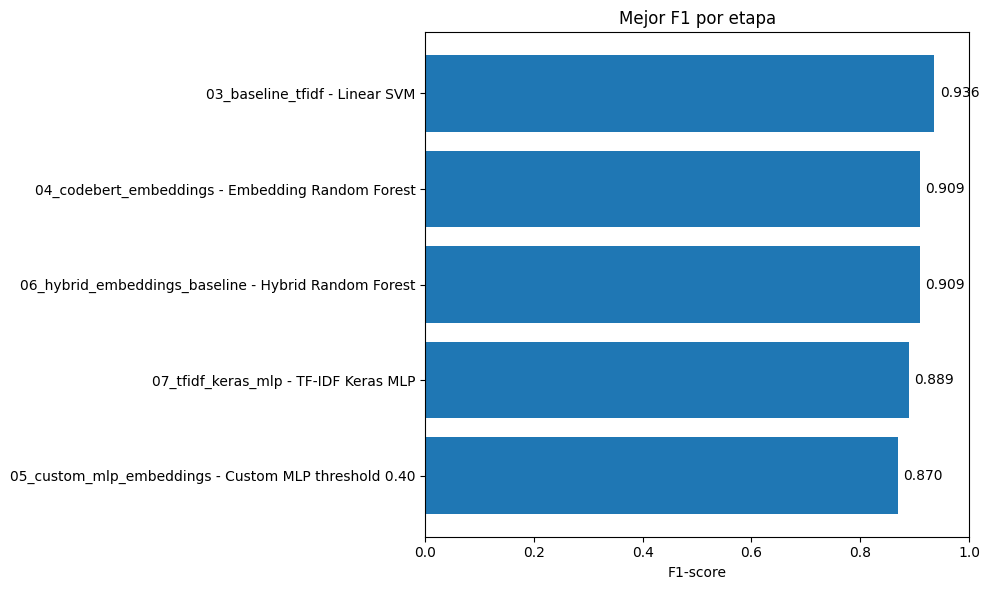

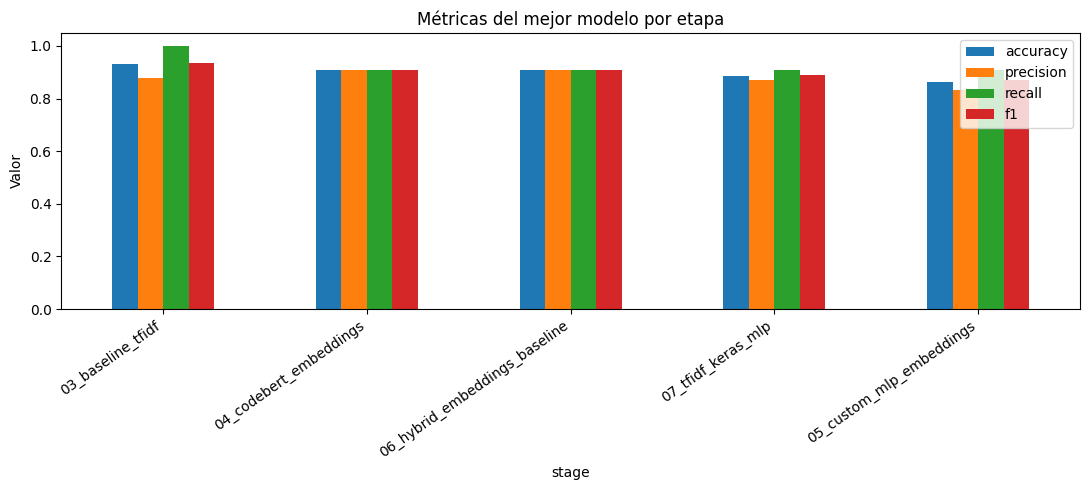

In [7]:
plot_df = best_by_stage.sort_values('f1', ascending=True).copy()
labels = plot_df['stage'] + ' - ' + plot_df['model']

plt.figure(figsize=(10, 6))
plt.barh(labels, plot_df['f1'])
plt.xlabel('F1-score')
plt.title('Mejor F1 por etapa')
plt.xlim(0, 1.0)
for idx, value in enumerate(plot_df['f1']):
    plt.text(value + 0.01, idx, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
metric_plot_df = best_by_stage.set_index('stage')[metrics_to_plot]
metric_plot_df.plot(kind='bar', figsize=(11, 5))
plt.ylim(0, 1.05)
plt.ylabel('Valor')
plt.title('Métricas del mejor modelo por etapa')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


## 7. Matrices de confusión consolidadas

A partir de tn, fp, fn y tp se reconstruye la matriz de confusión de cada mejor modelo por etapa.

Esto permite ver no solo quién tiene mejor F1, sino qué tipo de error comete: falsos positivos o falsos negativos.


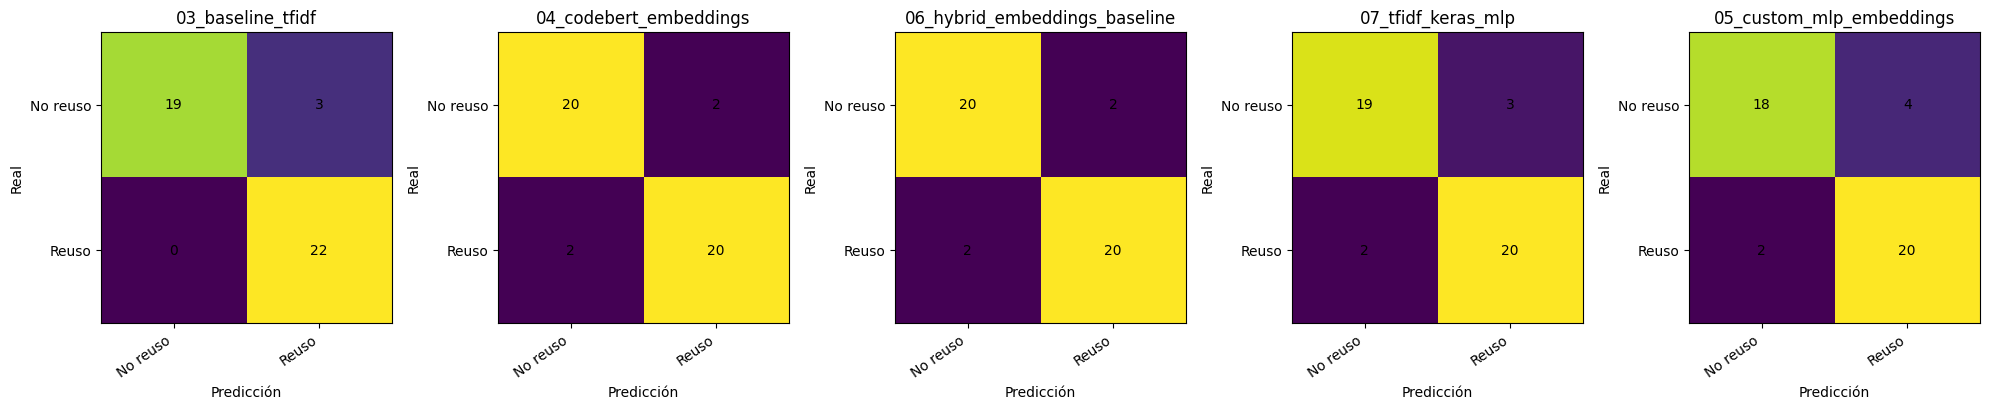

In [8]:
n_models = len(best_by_stage)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, best_by_stage.iterrows()):
    cm = np.array([
        [int(row['tn']), int(row['fp'])],
        [int(row['fn']), int(row['tp'])]
    ])
    im = ax.imshow(cm)
    ax.set_title(row['stage'])
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No reuso', 'Reuso'], rotation=35, ha='right')
    ax.set_yticklabels(['No reuso', 'Reuso'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()


### Interpretación de las matrices de confusión

El Linear SVM tiene 0 falsos negativos, por eso su recall es 1.0000. En detección de reuso esto es muy valioso, porque significa que no dejó pasar ningún caso positivo en validación.

Su costo son 3 falsos positivos. El modelo marca como reuso algunos pares que no lo eran, pero evita perder casos reales de reuso.

Los modelos de embeddings e híbrido tienen menos falsos positivos, pero cometen 2 falsos negativos. Por eso su F1 queda por debajo.


## 8. Análisis de predicciones y errores compartidos

Además de comparar métricas agregadas, se combinan las predicciones por pair_id para ver en qué ejemplos se equivocan los modelos y si los errores son compartidos.


In [9]:
prediction_specs = [
    ('03_baseline_tfidf', '03_val_predictions_baseline.csv', 'prediction'),
    ('04_codebert_embeddings', '04_val_predictions_transformer_embeddings.csv', 'prediction'),
    ('05_custom_mlp_embeddings', '05_custom_mlp_val_predictions.csv', 'prediction_best_threshold'),
    ('06_hybrid_embeddings_baseline', '06_hybrid_val_predictions.csv', 'prediction'),
    ('07_tfidf_keras_mlp', '07_tfidf_keras_val_predictions.csv', 'prediction_best_threshold'),
]

merged_predictions = None

for stage, file_name, pred_col in prediction_specs:
    path = REPORTS_PATH / file_name

    if not path.exists():
        print('No encontrado:', file_name)
        continue

    df = pd.read_csv(path)

    if pred_col not in df.columns or 'true_label' not in df.columns:
        print('Columnas insuficientes en:', file_name)
        continue

    keep_cols = ['pair_id', 'language', 'file_1', 'file_2', 'true_label', pred_col]
    keep_cols = [col for col in keep_cols if col in df.columns]
    temp = df[keep_cols].copy().rename(columns={pred_col: f'pred_{stage}'})

    if merged_predictions is None:
        merged_predictions = temp
    else:
        drop_cols = [col for col in ['language', 'file_1', 'file_2', 'true_label'] if col in temp.columns]
        temp = temp.drop(columns=drop_cols, errors='ignore')
        merged_predictions = merged_predictions.merge(temp, on='pair_id', how='outer')

pred_cols = [col for col in merged_predictions.columns if col.startswith('pred_')]

for col in pred_cols:
    stage = col.replace('pred_', '')
    merged_predictions[f'correct_{stage}'] = (merged_predictions[col] == merged_predictions['true_label']).astype('Int64')

correct_cols = [col for col in merged_predictions.columns if col.startswith('correct_')]
merged_predictions['n_models_correct'] = merged_predictions[correct_cols].sum(axis=1)
merged_predictions['n_models_wrong'] = len(correct_cols) - merged_predictions['n_models_correct']
merged_predictions['all_models_correct'] = merged_predictions['n_models_wrong'] == 0
merged_predictions['any_model_wrong'] = merged_predictions['n_models_wrong'] > 0

merged_predictions.to_csv(REPORTS_PATH / 'comparation_prediction_error_overlap.csv', index=False)

display(merged_predictions.head())
print('Pares evaluados:', len(merged_predictions))
print('Pares donde todos aciertan:', int(merged_predictions['all_models_correct'].sum()))
print('Pares donde al menos un modelo falla:', int(merged_predictions['any_model_wrong'].sum()))


,pair_id,language,file_1,file_2,true_label,pred_03_baseline_tfidf,pred_04_codebert_embeddings,pred_05_custom_mlp_embeddings,pred_06_hybrid_embeddings_baseline,pred_07_tfidf_keras_mlp,correct_03_baseline_tfidf,correct_04_codebert_embeddings,correct_05_custom_mlp_embeddings,correct_06_hybrid_embeddings_baseline,correct_07_tfidf_keras_mlp,n_models_correct,n_models_wrong,all_models_correct,any_model_wrong
0,train_pair_000001,c,027.c,050.c,0,0,0,0,0,0,1,1,1,1,1,5,0,True,False
1,train_pair_000003,java,039.java,128.java,0,0,0,0,0,1,1,1,1,1,0,4,1,False,True
2,train_pair_000011,java,015.java,023.java,1,1,1,1,1,1,1,1,1,1,1,5,0,True,False
3,train_pair_000014,java,101.java,212.java,1,1,1,1,1,1,1,1,1,1,1,5,0,True,False
4,train_pair_000025,c,074.c,032.c,0,0,0,0,0,0,1,1,1,1,1,5,0,True,False


Pares evaluados: 44
Pares donde todos aciertan: 33
Pares donde al menos un modelo falla: 11


## 9. Resumen de errores por modelo

Se cuentan falsos positivos, falsos negativos y errores totales usando las predicciones guardadas de cada etapa.


,stage,false_positives,false_negatives,total_errors
0,03_baseline_tfidf,3,0,3
1,04_codebert_embeddings,2,2,4
2,06_hybrid_embeddings_baseline,2,2,4
3,05_custom_mlp_embeddings,4,2,6
4,07_tfidf_keras_mlp,6,0,6


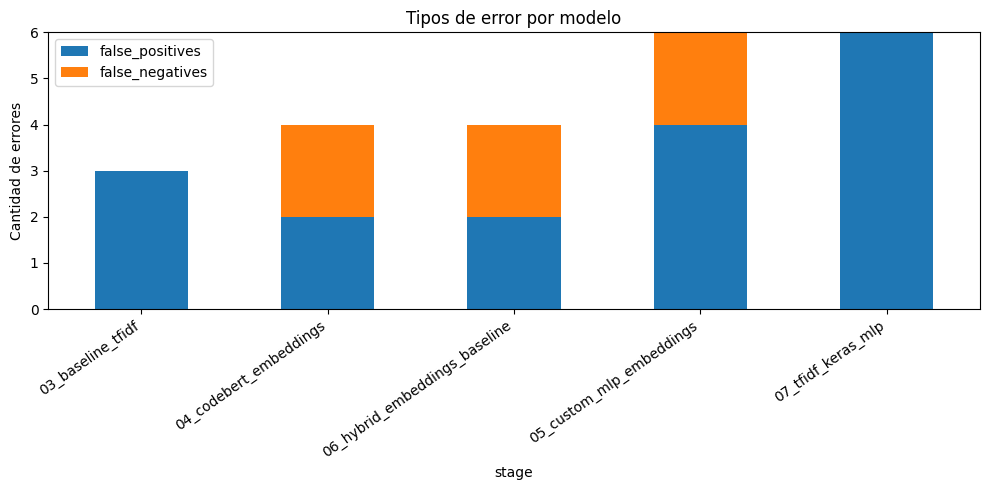

In [10]:
error_summary = []

for col in pred_cols:
    stage = col.replace('pred_', '')
    y_true = merged_predictions['true_label']
    y_pred = merged_predictions[col]
    mask = y_true.notna() & y_pred.notna()

    fp = int(((y_true[mask] == 0) & (y_pred[mask] == 1)).sum())
    fn = int(((y_true[mask] == 1) & (y_pred[mask] == 0)).sum())
    error_summary.append({
        'stage': stage,
        'false_positives': fp,
        'false_negatives': fn,
        'total_errors': fp + fn
    })

error_summary_df = pd.DataFrame(error_summary).sort_values('total_errors').reset_index(drop=True)
error_summary_df.to_csv(REPORTS_PATH / 'comparation_error_summary.csv', index=False)
display(error_summary_df)

error_summary_df.set_index('stage')[['false_positives', 'false_negatives']].plot(kind='bar', stacked=True, figsize=(10, 5))
plt.ylabel('Cantidad de errores')
plt.title('Tipos de error por modelo')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


### Interpretación del análisis de errores

El mejor modelo no es necesariamente el que tiene menos falsos positivos, sino el que logra el mejor equilibrio para el objetivo.

En este proyecto, el Linear SVM es especialmente fuerte porque tiene 0 falsos negativos. Para detección de reuso, eso significa que detecta todos los pares positivos de validación.

Los modelos de embeddings e híbrido reducen falsos positivos, pero fallan algunos positivos reales, lo que reduce su recall.


## 10. Casos difíciles

Los casos difíciles son pares donde varios modelos fallan. Revisarlos puede revelar patrones problemáticos: códigos muy cortos, códigos con estructura similar pero diferente propósito, o pares positivos con modificaciones fuertes.


In [11]:
hard_cases = merged_predictions.sort_values(
    ['n_models_wrong', 'true_label'],
    ascending=[False, False]
)

hard_cases_to_show = [
    'pair_id', 'language', 'file_1', 'file_2', 'true_label',
    'n_models_correct', 'n_models_wrong'
] + pred_cols

display(hard_cases[hard_cases_to_show].head(15))


,pair_id,language,file_1,file_2,true_label,n_models_correct,n_models_wrong,pred_03_baseline_tfidf,pred_04_codebert_embeddings,pred_05_custom_mlp_embeddings,pred_06_hybrid_embeddings_baseline,pred_07_tfidf_keras_mlp
13,train_pair_000070,java,086.java,240.java,0,0,5,1,1,1,1,1
10,train_pair_000054,c,060.c,045.c,0,1,4,1,1,1,1,0
18,train_pair_000085,java,135.java,174.java,1,2,3,1,0,0,0,1
27,train_pair_000146,c,009.c,064.c,0,2,3,1,0,1,0,1
29,train_pair_000164,java,062.java,190.java,0,3,2,0,0,1,0,1
8,train_pair_000044,java,136.java,173.java,1,4,1,1,1,0,1,1
11,train_pair_000057,java,106.java,111.java,1,4,1,1,0,1,1,1
23,train_pair_000123,c,027.c,065.c,1,4,1,1,1,1,0,1
1,train_pair_000003,java,039.java,128.java,0,4,1,0,0,0,0,1
21,train_pair_000109,java,029.java,093.java,0,4,1,0,0,0,0,1


## 11. Selección final del modelo

A partir de la comparación consolidada, se selecciona como modelo final el que tenga mayor F1. En caso de empate, se prioriza mayor recall, luego mayor precision y luego mayor accuracy.


In [12]:
final_ranking = all_candidates.sort_values(
    ['f1', 'recall', 'precision', 'accuracy'],
    ascending=False
).reset_index(drop=True)

selected_model = final_ranking.iloc[0].copy()
selected_model.to_frame().T.to_csv(REPORTS_PATH / 'comparation_selected_final_model.csv', index=False)

display(selected_model.to_frame(name='valor'))

print('Modelo seleccionado:', selected_model['model'])
print('Etapa:', selected_model['stage'])
print('F1:', round(selected_model['f1'], 4))
print('Recall:', round(selected_model['recall'], 4))
print('Precision:', round(selected_model['precision'], 4))


,valor
stage,03_baseline_tfidf
family,TF-IDF clásico
model,Linear SVM
accuracy,0.931818
precision,0.88
recall,1.0
f1,0.93617
tn,19
fp,3
fn,0


Modelo seleccionado: Linear SVM
Etapa: 03_baseline_tfidf
F1: 0.9362
Recall: 1.0
Precision: 0.88


### Conclusión final

El modelo seleccionado es Linear SVM con TF-IDF del notebook 03.

Razones principales:

- Tiene el F1 más alto: 0.9362.
- Tiene recall perfecto: 1.0000.
- No comete falsos negativos en validación.
- Usa una representación relativamente simple, reproducible y menos costosa que embeddings de transformer.

La conclusión experimental es importante: en este dataset, los enfoques más complejos no superaron al baseline clásico. Esto no significa que CodeBERT o las redes neuronales no sirvan, sino que con pocos datos y embeddings congelados no lograron mejorar la señal fuerte que ya capturaba TF-IDF.


## 12. Archivos generados por este notebook

Este notebook genera reportes consolidados en data/reports:

- comparation_all_model_candidates.csv
- comparation_best_by_stage.csv
- comparation_best_overall.csv
- comparation_prediction_error_overlap.csv
- comparation_error_summary.csv
- comparation_selected_final_model.csv

Estos archivos dejan documentada la comparación final y facilitan incluir tablas en el reporte del proyecto.
